# LTAT.05.025 – Business Process Mining: Project
## Task 1: Event Log Inspection
**Team:** Hashim Ali, Calvin, Ahmed, Shokat  
**Dataset:** CoatXR P2P Process – 10 Vendors  

---

### Objective
Analyze the event log to:
1. Identify all key columns and explain their meaning
2. Examine value distributions
3. Identify relationships between columns
4. Flag columns with limited analytical value

> **Note for teammates:** Run this notebook fully. The final cell exports `cases_df` (one row per case) as a shared CSV that other tasks can import directly — no re-processing needed.

## 0. Setup & Data Loading

In [1]:
# Install / import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from IPython.display import display

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:,.2f}'.format)
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
print('Libraries loaded.')

Libraries loaded.


In [3]:
# ─── LOAD DATA ───────────────────────────────────────────────────────────────
# If running on Google Colab, upload the .gz file using the Files panel (left sidebar)
# then update FILE_PATH below. The file can be read directly as gzip-compressed CSV.

FILE_PATH = '/content/P2P_CoatXR_10_vendors.csv.gz'  # <-- updated file path

df = pd.read_csv(
    FILE_PATH,
    compression='gzip',
    parse_dates=['timestamp']
)

# Clean up column names for easier access
df.columns = [c.strip().replace('(case) ', '').replace('lifecycle:', '') for c in df.columns]

print(f'Loaded {len(df):,} events | {df["Case Identifier"].nunique():,} unique cases | {df["label"].nunique()} unique activities')
df.head(3)

Loaded 311,821 events | 59,385 unique cases | 21 unique activities


,User,resource,timestamp,transition,label,Name,Source,Purchasing Document,Item,Purch. Doc. Category name,Item Type,Sub spend area text,Case Identifier,Spend area text,Document Type,Cumulative net worth (EUR),Company,Spend classification text,Vendor,Item Category,GR-Based Inv. Verif.,Goods Receipt
0,batch_03,batch_03,2018-01-01 03:42:00,complete,Create Purchase Order Item,vendor_0103,sourceSystemID_0000,4507000221,10,Purchase order,Standard,Labels,4507000221_00010,Packaging,Standard PO,208.00,companyID_0000,PR,vendorID_0103,"3-way match, invoice before GR",False,True
1,user_029,user_029,2018-01-02 11:04:00,complete,Receive Order Confirmation,vendor_0103,sourceSystemID_0000,4507000221,10,Purchase order,Standard,Labels,4507000221_00010,Packaging,Standard PO,208.00,companyID_0000,PR,vendorID_0103,"3-way match, invoice before GR",False,True
2,user_030,user_030,2018-01-05 13:36:00,complete,Record Goods Receipt,vendor_0103,sourceSystemID_0000,4507000221,10,Purchase order,Standard,Labels,4507000221_00010,Packaging,Standard PO,208.00,companyID_0000,PR,vendorID_0103,"3-way match, invoice before GR",False,True


## 1.1 – Column Overview: What Does Each Column Represent?

Before running any analysis, we inspect every column systematically: its dtype, number of unique values, null rate, and sample values.

In [4]:
# ─── COLUMN INVENTORY ────────────────────────────────────────────────────────
summary_rows = []
for col in df.columns:
    n_unique = df[col].nunique()
    null_pct = df[col].isna().mean() * 100
    sample   = df[col].dropna().unique()[:4].tolist()
    summary_rows.append({
        'Column': col,
        'Dtype': str(df[col].dtype),
        'Unique Values': n_unique,
        'Null %': round(null_pct, 2),
        'Sample Values': sample
    })

col_summary = pd.DataFrame(summary_rows)
display(col_summary)

,Column,Dtype,Unique Values,Null %,Sample Values
0,User,object,227,0.00,"[batch_03, user_029, user_030, user_024]"
1,resource,object,227,0.00,"[batch_03, user_029, user_030, user_024]"
2,timestamp,datetime64[ns],41952,0.00,"[2018-01-01 03:42:00, 2018-01-02 11:04:00, 201..."
3,transition,object,1,0.00,[complete]
4,label,object,21,0.00,"[Create Purchase Order Item, Receive Order Con..."
5,Name,object,10,0.00,"[vendor_0103, vendor_0104, vendor_0106, vendor..."
6,Source,object,1,0.00,[sourceSystemID_0000]
7,Purchasing Document,int64,9118,0.00,"[4507000221, 4507000222, 4507000223, 4507000225]"
8,Item,int64,430,0.00,"[10, 20, 30, 40]"
9,Purch. Doc. Category name,object,1,0.00,[Purchase order]


### Column Interpretation (Justified)

| Column | Role | Interpretation & Evidence |
|---|---|---|
| `User` / `resource` | Event attribute | Identical columns — the anonymized user/system that performed the activity. `batch_03` suggests automated batch jobs; `NONE` means system-generated. |
| `timestamp` | Event attribute | Datetime of when the activity completed. All events have `transition = complete`. |
| `transition` | Event attribute | Always `complete` — no start events recorded. Single lifecycle state. |
| `label` | **Key** event attribute | The activity name. 21 unique activities including 5 BPMN milestones + change/cancel/admin activities. |
| `Name` | Case attribute | Same as `Vendor` (mapped to vendor name string like `vendor_0103`). Redundant with `Vendor`. |
| `Source` | Case attribute | Always `sourceSystemID_0000` — single source ERP system (SAP). Zero analytical value. |
| `Purchasing Document` | **Key** case attribute | Anonymized ID of the purchase order. Multiple line items share one document. |
| `Item` | Case attribute | Line-item number within a purchasing document (e.g., `00010`, `00020`). |
| `Case Identifier` | **Key** case identifier | `PurchasingDocument_Item` — unique identifier per case (line item). |
| `Purch. Doc. Category name` | Case attribute | Always `Purchase order` — no analytical value in this dataset. |
| `Item Type` | **Key** case attribute | 4 types: `Standard`, `Consignment`, `Third-party`, `Service`. Consignment has different process flow. |
| `Sub spend area text` | **Key** case attribute | 10 sub-categories (e.g., `Labels`, `Metal Containers & Lids < 30L`). Used in SLA analysis (Task 3). |
| `Spend area text` | Case attribute | Higher-level grouping of spend (e.g., `Packaging`, `Trading & End Products`). Parent of Sub spend area. |
| `Document Type` | Case attribute | `Standard PO` or `Framework order` — indicates whether a blanket/framework contract is used. |
| `Cumulative net worth (EUR)` | **Key** case attribute | Financial value of the line item in EUR. Useful for value-weighted analyses. |
| `Company` | Case attribute | Always `companyID_0000` — single company. Zero analytical value. |
| `Spend classification text` | Case attribute | `PR` (procurement), `NPR` (non-procurement), `OTHER`. Classifies spending type. |
| `Vendor` | **Key** case attribute | Anonymized vendor ID (10 unique). Main dimension for Task 10. |
| `Item Category` | **Key** case attribute | Invoice matching type: `3-way match invoice before GR`, `3-way match invoice after GR`, `Consignment`. |
| `GR-Based Inv. Verif.` | Case attribute | Boolean — whether goods receipt must occur before invoice can be verified. |
| `Goods Receipt` | Case attribute | Always `true` — no analytical value in this subset. |

## 1.2 – Activity Distribution
How often does each activity appear? Which are the 5 BPMN milestone activities?

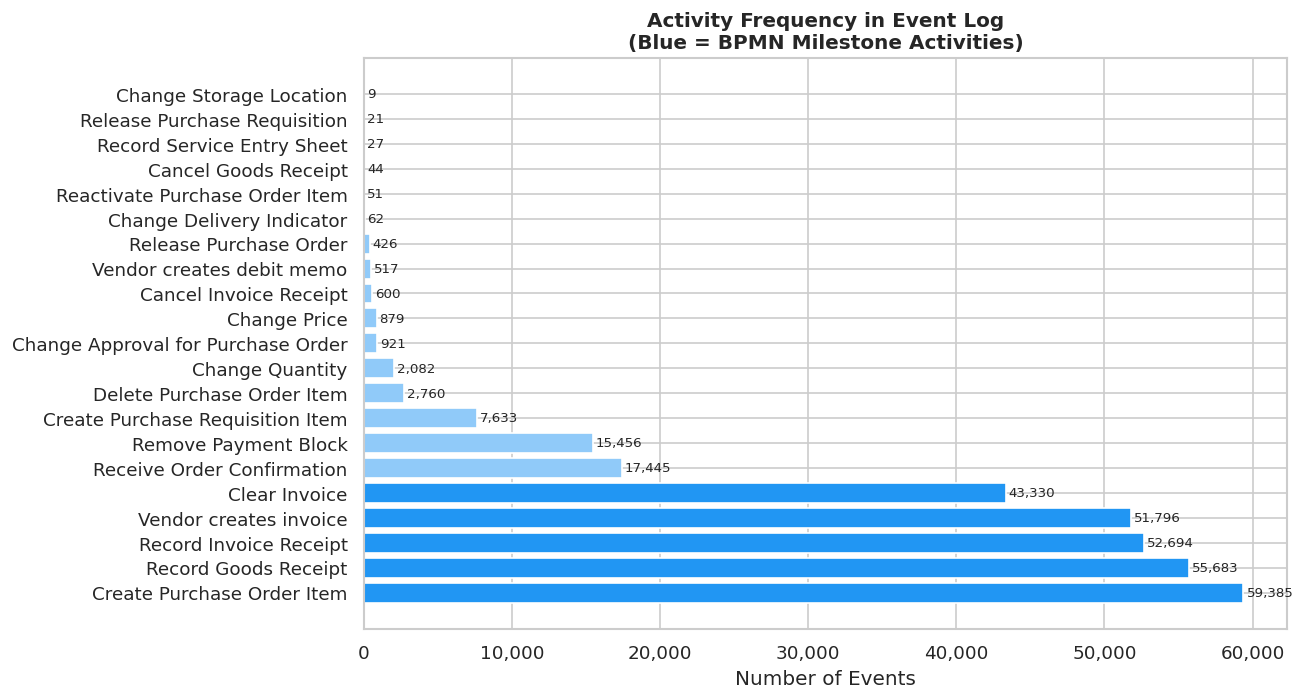

,Activity,Count,% of Events,Is Milestone
0,Create Purchase Order Item,59385,19.04,True
1,Record Goods Receipt,55683,17.86,True
2,Record Invoice Receipt,52694,16.90,True
3,Vendor creates invoice,51796,16.61,True
4,Clear Invoice,43330,13.90,True
5,Receive Order Confirmation,17445,5.59,False
6,Remove Payment Block,15456,4.96,False
7,Create Purchase Requisition Item,7633,2.45,False
8,Delete Purchase Order Item,2760,0.89,False
9,Change Quantity,2082,0.67,False


In [5]:
# ─── ACTIVITY FREQUENCY ──────────────────────────────────────────────────────
MILESTONES = [
    'Create Purchase Order Item',
    'Record Goods Receipt',
    'Vendor creates invoice',
    'Record Invoice Receipt',
    'Clear Invoice'
]

act_counts = df['label'].value_counts().reset_index()
act_counts.columns = ['Activity', 'Count']
act_counts['% of Events'] = (act_counts['Count'] / len(df) * 100).round(2)
act_counts['Is Milestone'] = act_counts['Activity'].isin(MILESTONES)

fig, ax = plt.subplots(figsize=(11, 6))
colors = ['#2196F3' if m else '#90CAF9' for m in act_counts['Is Milestone']]
bars = ax.barh(act_counts['Activity'], act_counts['Count'], color=colors)
ax.set_xlabel('Number of Events')
ax.set_title('Activity Frequency in Event Log\n(Blue = BPMN Milestone Activities)', fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
for bar, count in zip(bars, act_counts['Count']):
    ax.text(bar.get_width() + 200, bar.get_y() + bar.get_height()/2,
            f'{count:,}', va='center', fontsize=8)
plt.tight_layout()
plt.savefig('task1_activity_frequency.png', bbox_inches='tight')
plt.show()

display(act_counts)

## 1.3 – Case-Level Statistics
How many events per case? Min, max, median.

Events per case statistics:
Total Cases   59,385.00
Mean Events        5.25
Std Dev            1.43
Min                1.00
Q1                 5.00
Median             5.00
Q3                 6.00
Max               13.00


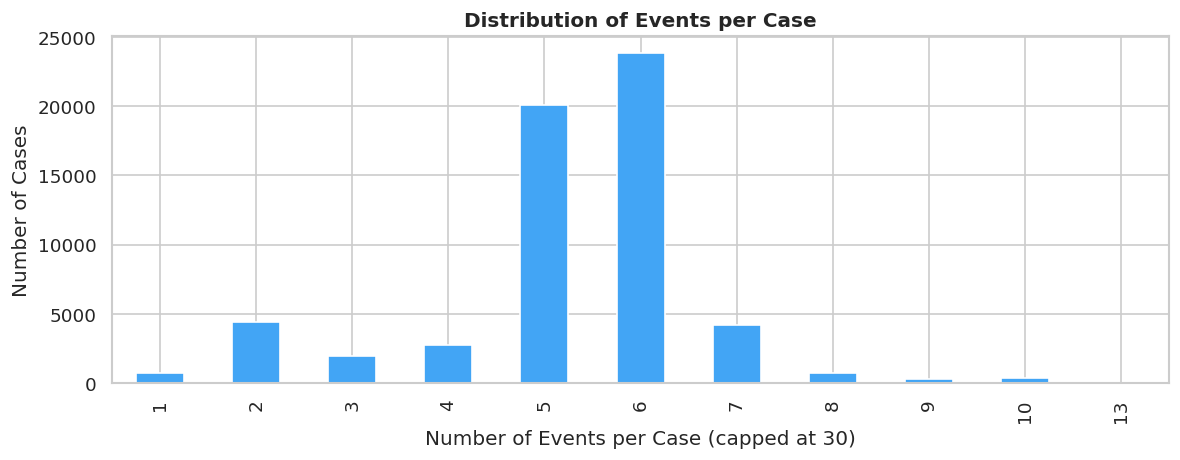

In [6]:
# ─── EVENTS PER CASE ─────────────────────────────────────────────────────────
events_per_case = df.groupby('Case Identifier').size()

print('Events per case statistics:')
print(events_per_case.describe().rename({
    'count': 'Total Cases', 'mean': 'Mean Events', 'std': 'Std Dev',
    'min': 'Min', '25%': 'Q1', '50%': 'Median', '75%': 'Q3', 'max': 'Max'
}).to_string())

fig, ax = plt.subplots(figsize=(10, 4))
events_per_case.clip(upper=30).value_counts().sort_index().plot(kind='bar', ax=ax, color='#42A5F5')
ax.set_xlabel('Number of Events per Case (capped at 30)')
ax.set_ylabel('Number of Cases')
ax.set_title('Distribution of Events per Case', fontweight='bold')
plt.tight_layout()
plt.savefig('task1_events_per_case.png', bbox_inches='tight')
plt.show()

## 1.4 – Key Categorical Column Distributions
Inspect the key case-level attributes.

Case-level dataframe: 59,385 rows (one per case)



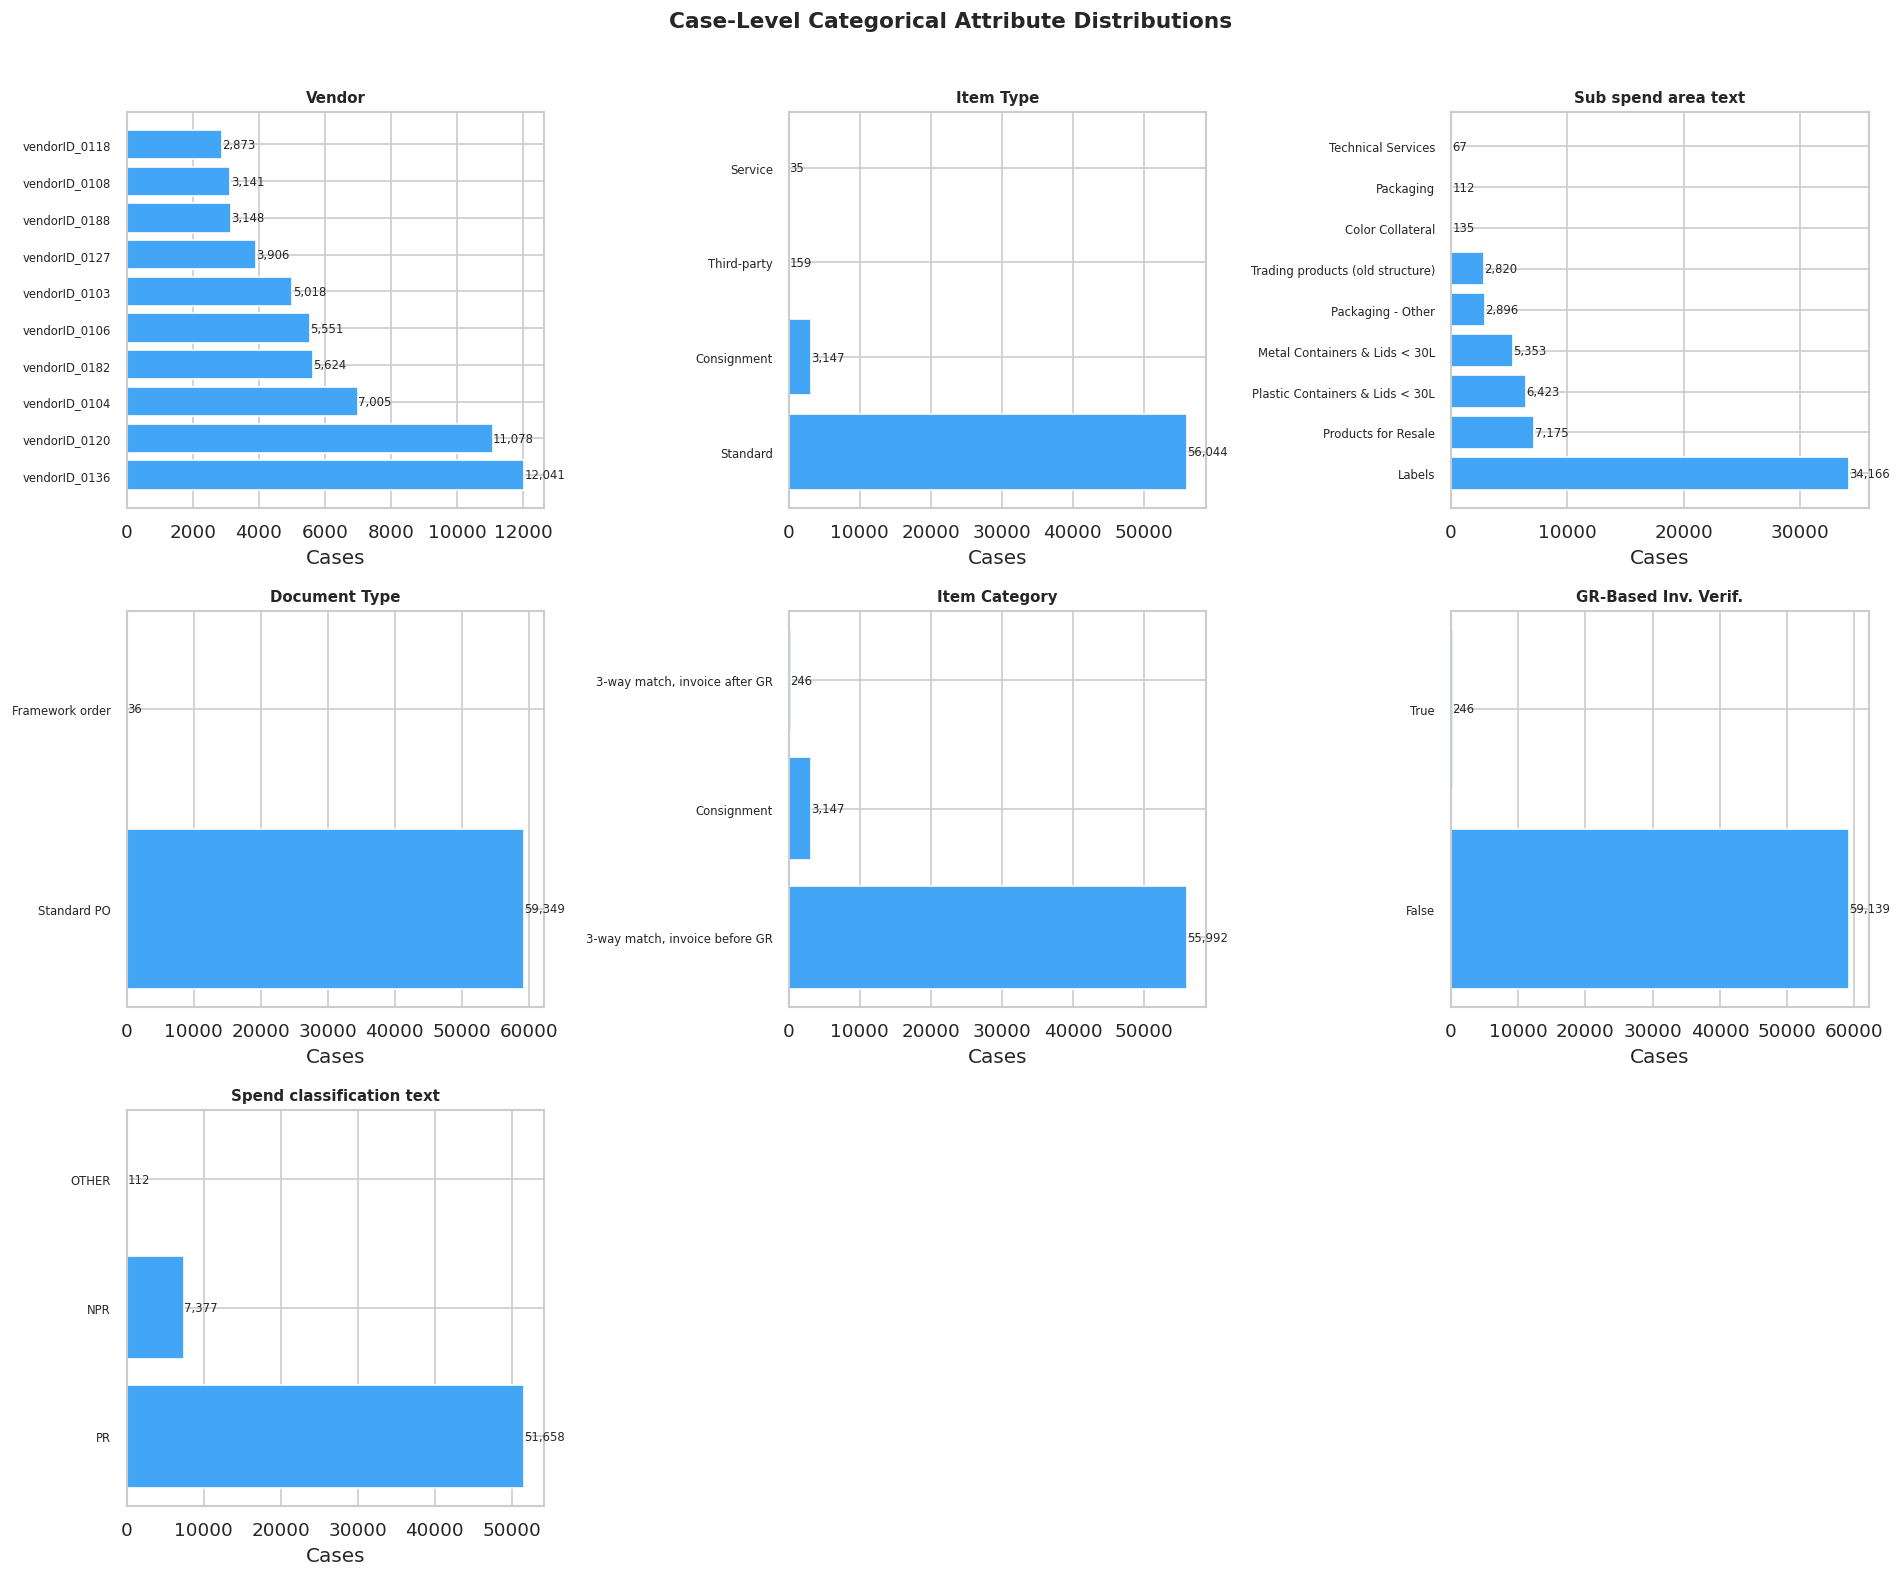

In [7]:
# ─── CASE-LEVEL ATTRIBUTE DISTRIBUTIONS ──────────────────────────────────────
# Build one row per case for case-level attributes
CASE_ATTRS = [
    'Case Identifier', 'Purchasing Document', 'Vendor', 'Item Type',
    'Sub spend area text', 'Spend area text', 'Document Type',
    'Cumulative net worth (EUR)', 'Spend classification text',
    'Item Category', 'GR-Based Inv. Verif.'
]

cases_attrs = df[CASE_ATTRS].drop_duplicates(subset='Case Identifier')
print(f'Case-level dataframe: {len(cases_attrs):,} rows (one per case)\n')

cat_cols = ['Vendor', 'Item Type', 'Sub spend area text',
            'Document Type', 'Item Category', 'GR-Based Inv. Verif.',
            'Spend classification text']

fig, axes = plt.subplots(3, 3, figsize=(16, 13))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    counts = cases_attrs[col].value_counts()
    axes[i].barh(counts.index.astype(str), counts.values, color='#42A5F5')
    axes[i].set_title(col, fontweight='bold', fontsize=9)
    axes[i].set_xlabel('Cases')
    axes[i].tick_params(axis='y', labelsize=7)
    for j, (idx, val) in enumerate(zip(counts.index, counts.values)):
        axes[i].text(val + 10, j, f'{val:,}', va='center', fontsize=7)

# Hide unused subplots
for k in range(len(cat_cols), len(axes)):
    axes[k].set_visible(False)

plt.suptitle('Case-Level Categorical Attribute Distributions', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('task1_categorical_distributions.png', bbox_inches='tight')
plt.show()

## 1.5 – Net Worth Distribution
What is the financial spread of line items?

Net worth (EUR) statistics:
count    59,385.00
mean        973.74
std       4,435.49
min           0.00
25%         144.00
50%         326.00
75%         854.00
max     959,123.00


/tmp/ipykernel_9959/361666471.py:27: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(vendor_data_sorted, labels=vendor_labels, vert=True)


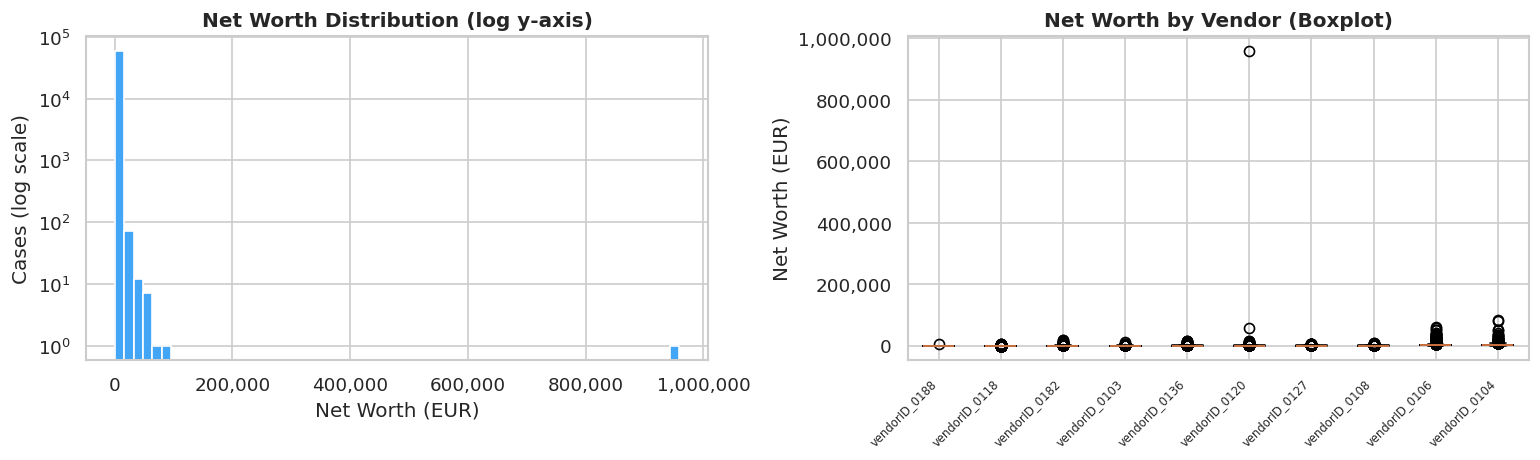

In [8]:
# ─── NET WORTH ANALYSIS ───────────────────────────────────────────────────────
cases_attrs['Cumulative net worth (EUR)'] = pd.to_numeric(
    cases_attrs['Cumulative net worth (EUR)'], errors='coerce'
)

print('Net worth (EUR) statistics:')
print(cases_attrs['Cumulative net worth (EUR)'].describe().to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Histogram (log scale)
axes[0].hist(cases_attrs['Cumulative net worth (EUR)'].dropna(), bins=60, color='#42A5F5', edgecolor='white')
axes[0].set_yscale('log')
axes[0].set_xlabel('Net Worth (EUR)')
axes[0].set_ylabel('Cases (log scale)')
axes[0].set_title('Net Worth Distribution (log y-axis)', fontweight='bold')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

# By vendor – boxplot
vendor_data = []
for v, g in cases_attrs.groupby('Vendor'):
    vendor_data.append(g['Cumulative net worth (EUR)'].dropna().values)
vendor_labels = cases_attrs.groupby('Vendor')['Cumulative net worth (EUR)'].median().sort_values().index.tolist()
vendor_data_sorted = [cases_attrs[cases_attrs['Vendor'] == v]['Cumulative net worth (EUR)'].dropna().values
                       for v in vendor_labels]

axes[1].boxplot(vendor_data_sorted, labels=vendor_labels, vert=True)
axes[1].set_xticklabels(vendor_labels, rotation=45, ha='right', fontsize=7)
axes[1].set_ylabel('Net Worth (EUR)')
axes[1].set_title('Net Worth by Vendor (Boxplot)', fontweight='bold')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))

plt.tight_layout()
plt.savefig('task1_networth_distribution.png', bbox_inches='tight')
plt.show()

## 1.6 – Temporal Coverage
What time period does the log cover? Is it uniform?

Log start : 2018-01-01 03:42:00
Log end   : 2018-12-31 14:49:00
Duration  : 364 days 11:07:00


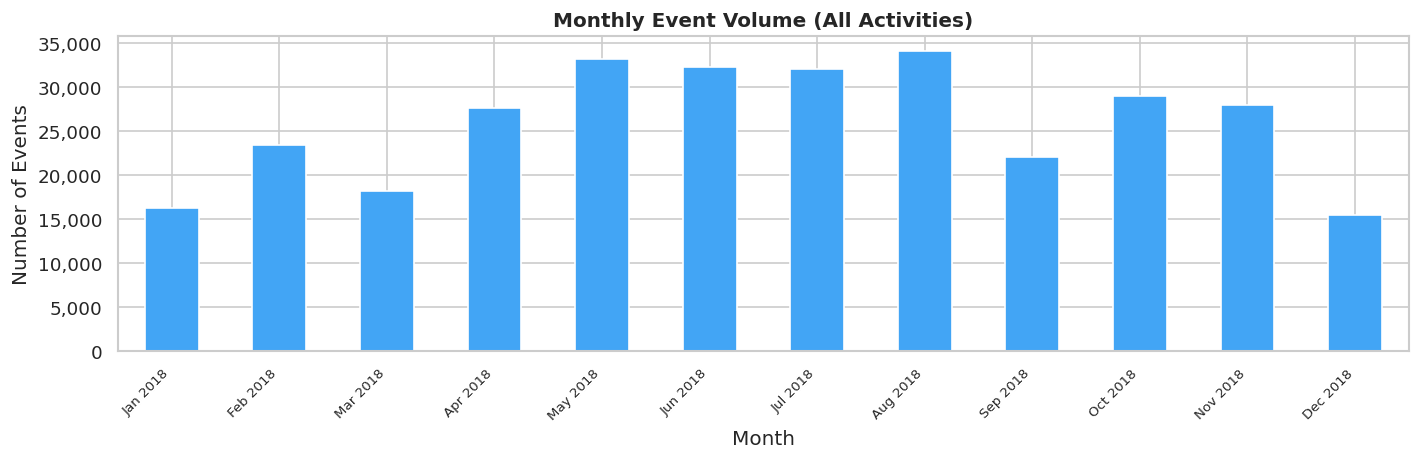

In [9]:
# ─── TEMPORAL COVERAGE ───────────────────────────────────────────────────────
print(f"Log start : {df['timestamp'].min()}")
print(f"Log end   : {df['timestamp'].max()}")
print(f"Duration  : {df['timestamp'].max() - df['timestamp'].min()}")

monthly_events = df.set_index('timestamp').resample('ME')['label'].count()

fig, ax = plt.subplots(figsize=(12, 4))
monthly_events.plot(kind='bar', ax=ax, color='#42A5F5')
ax.set_xlabel('Month')
ax.set_ylabel('Number of Events')
ax.set_title('Monthly Event Volume (All Activities)', fontweight='bold')
ax.set_xticklabels([x.strftime('%b %Y') for x in monthly_events.index], rotation=45, ha='right', fontsize=8)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.tight_layout()
plt.savefig('task1_monthly_events.png', bbox_inches='tight')
plt.show()

## 1.7 – Relationships Between Columns
Are there meaningful correlations between case attributes? E.g., does Item Category relate to Item Type? Does Vendor relate to Spend Area?

=== Item Type vs Item Category ===


Item Category,"3-way match, invoice after GR","3-way match, invoice before GR",Consignment
Item Type,,,
Consignment,0,0,3147
Service,35,0,0
Standard,211,55833,0
Third-party,0,159,0


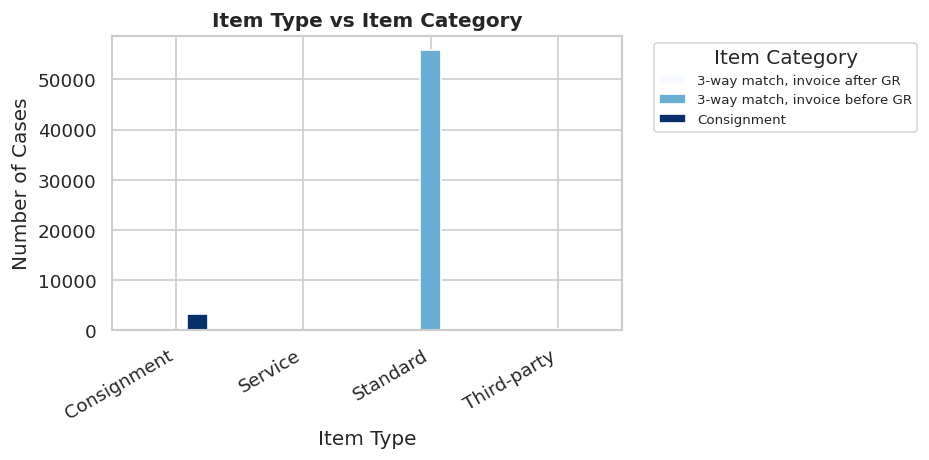

In [10]:
# ─── ITEM TYPE vs ITEM CATEGORY ──────────────────────────────────────────────
ct1 = pd.crosstab(cases_attrs['Item Type'], cases_attrs['Item Category'])
print('=== Item Type vs Item Category ===')
display(ct1)

fig, ax = plt.subplots(figsize=(8, 4))
ct1.plot(kind='bar', ax=ax, colormap='Blues')
ax.set_title('Item Type vs Item Category', fontweight='bold')
ax.set_xlabel('Item Type')
ax.set_ylabel('Number of Cases')
ax.legend(title='Item Category', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('task1_itemtype_vs_category.png', bbox_inches='tight')
plt.show()

=== Vendor vs Sub Spend Area Text ===


Sub spend area text,Color Collateral,Labels,Metal Containers & Lids < 30L,Packaging,Packaging - Other,Plastic Containers & Lids < 30L,Products for Resale,Technical Services,Trading products (old structure)
Vendor,,,,,,,,,
vendorID_0103,0,3937,0,7,944,0,0,0,72
vendorID_0104,0,0,0,31,551,6423,0,0,0
vendorID_0106,0,24,5351,13,45,0,0,0,0
vendorID_0108,0,0,0,0,0,0,3141,0,0
vendorID_0118,0,0,0,0,0,0,128,0,2745
vendorID_0120,0,10755,0,5,292,0,0,0,3
vendorID_0127,0,0,0,0,0,0,3906,0,0
vendorID_0136,0,11084,0,0,890,0,0,67,0
vendorID_0182,0,5405,0,56,124,0,0,0,0


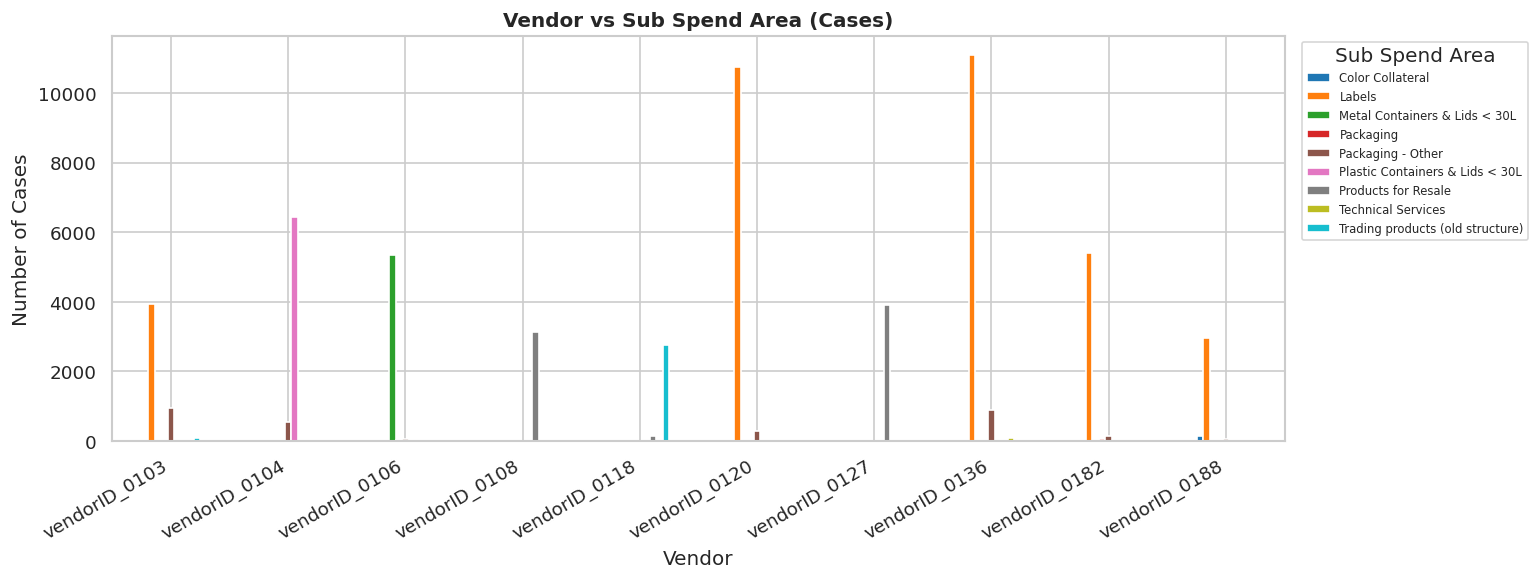

In [11]:
# ─── VENDOR vs SUB SPEND AREA ────────────────────────────────────────────────
ct2 = pd.crosstab(cases_attrs['Vendor'], cases_attrs['Sub spend area text'])
print('=== Vendor vs Sub Spend Area Text ===')
display(ct2)

fig, ax = plt.subplots(figsize=(13, 5))
ct2.plot(kind='bar', ax=ax, colormap='tab10')
ax.set_title('Vendor vs Sub Spend Area (Cases)', fontweight='bold')
ax.set_xlabel('Vendor')
ax.set_ylabel('Number of Cases')
ax.legend(title='Sub Spend Area', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=7)
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig('task1_vendor_vs_spendarea.png', bbox_inches='tight')
plt.show()

In [12]:
# ─── GR-BASED INV. VERIF. vs ITEM CATEGORY ───────────────────────────────────
ct3 = pd.crosstab(cases_attrs['GR-Based Inv. Verif.'], cases_attrs['Item Category'])
print('=== GR-Based Invoice Verification vs Item Category ===')
display(ct3)
# Interpretation: GR-Based flag should be True for "after GR" category — verify here

=== GR-Based Invoice Verification vs Item Category ===


Item Category,"3-way match, invoice after GR","3-way match, invoice before GR",Consignment
GR-Based Inv. Verif.,,,
False,0,55992,3147
True,246,0,0


## 1.8 – Completed vs Ongoing Cases
Per the project description: a case is **completed** if the *last* event is `Clear Invoice` or `Record Goods Receipt`. All others are **ongoing**.

Case completion status:
Status
Completed    46229
Ongoing      13156

Completed: 46,229 (77.8%)
Ongoing  : 13,156 (22.2%)


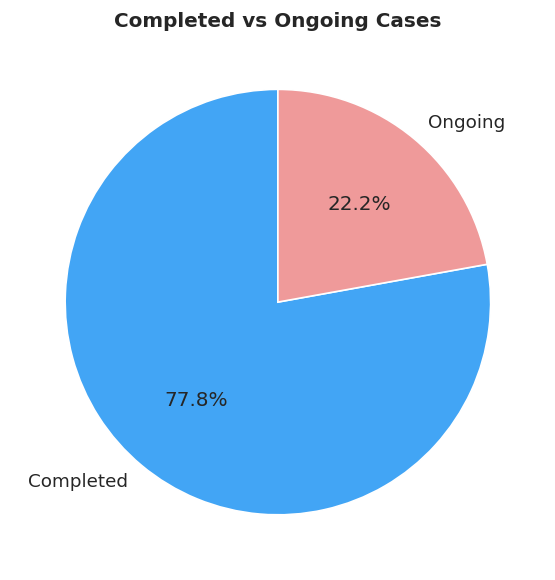

In [13]:
# ─── COMPLETED vs ONGOING ─────────────────────────────────────────────────────
COMPLETED_LAST_ACTIVITIES = {'Clear Invoice', 'Record Goods Receipt'}

last_activity = (
    df.sort_values('timestamp')
      .groupby('Case Identifier')['label']
      .last()
      .reset_index()
)
last_activity.columns = ['Case Identifier', 'Last Activity']
last_activity['Status'] = last_activity['Last Activity'].apply(
    lambda x: 'Completed' if x in COMPLETED_LAST_ACTIVITIES else 'Ongoing'
)

status_counts = last_activity['Status'].value_counts()
print('Case completion status:')
print(status_counts.to_string())
print(f"\nCompleted: {status_counts.get('Completed', 0):,} ({status_counts.get('Completed', 0)/len(last_activity)*100:.1f}%)")
print(f"Ongoing  : {status_counts.get('Ongoing', 0):,} ({status_counts.get('Ongoing', 0)/len(last_activity)*100:.1f}%)")

fig, ax = plt.subplots(figsize=(5, 5))
ax.pie(status_counts.values, labels=status_counts.index,
       autopct='%1.1f%%', colors=['#42A5F5', '#EF9A9A'], startangle=90)
ax.set_title('Completed vs Ongoing Cases', fontweight='bold')
plt.tight_layout()
plt.savefig('task1_completed_vs_ongoing.png', bbox_inches='tight')
plt.show()

## 1.9 – Consignment Cases
The Consignment item type follows a *different* process without invoices. We identify and separate these cases.

In [14]:
# ─── CONSIGNMENT CASES ───────────────────────────────────────────────────────
consignment_cases = cases_attrs[cases_attrs['Item Type'] == 'Consignment']['Case Identifier']
print(f'Consignment cases: {len(consignment_cases):,} ({len(consignment_cases)/len(cases_attrs)*100:.1f}%)')

# What activities appear in consignment cases?
consignment_acts = df[df['Case Identifier'].isin(consignment_cases)]['label'].value_counts()
print('\nActivities in Consignment cases:')
display(consignment_acts.reset_index().rename(columns={'label': 'Activity', 'count': 'Count'}))

# Confirm no invoice-related activities
invoice_acts = {'Vendor creates invoice', 'Record Invoice Receipt', 'Clear Invoice'}
has_invoice = any(act in consignment_acts.index for act in invoice_acts)
print(f'\nConsignment cases have invoice activities: {has_invoice}')

Consignment cases: 3,147 (5.3%)

Activities in Consignment cases:


,Activity,Count
0,Create Purchase Order Item,3147
1,Record Goods Receipt,2929
2,Change Quantity,144
3,Delete Purchase Order Item,113
4,Change Delivery Indicator,32
5,Receive Order Confirmation,26
6,Create Purchase Requisition Item,20
7,Cancel Goods Receipt,1



Consignment cases have invoice activities: False


## 1.10 – Summary Findings & Shared Output

Build and export the **shared case-level DataFrame** for teammates to use in Tasks 2–11.

In [15]:
# ─── BUILD SHARED CASE-LEVEL DATAFRAME ───────────────────────────────────────
# For each case: first/last timestamp, cycle time, status, activity count, and all attributes

case_times = (
    df.sort_values('timestamp')
      .groupby('Case Identifier')
      .agg(
          start_time=('timestamp', 'first'),
          end_time=('timestamp', 'last'),
          event_count=('label', 'count')
      )
      .reset_index()
)
case_times['cycle_time_days'] = (
    case_times['end_time'] - case_times['start_time']
).dt.total_seconds() / 86400

cases_df = (
    case_times
    .merge(last_activity, on='Case Identifier')
    .merge(cases_attrs, on='Case Identifier')
)
cases_df['Cumulative net worth (EUR)'] = pd.to_numeric(
    cases_df['Cumulative net worth (EUR)'], errors='coerce'
)

print(f'Shared cases_df: {len(cases_df):,} rows × {cases_df.shape[1]} columns')
print('\nColumns:', cases_df.columns.tolist())
display(cases_df.head(3))

Shared cases_df: 59,385 rows × 17 columns

Columns: ['Case Identifier', 'start_time', 'end_time', 'event_count', 'cycle_time_days', 'Last Activity', 'Status', 'Purchasing Document', 'Vendor', 'Item Type', 'Sub spend area text', 'Spend area text', 'Document Type', 'Cumulative net worth (EUR)', 'Spend classification text', 'Item Category', 'GR-Based Inv. Verif.']


,Case Identifier,start_time,end_time,event_count,cycle_time_days,Last Activity,Status,Purchasing Document,Vendor,Item Type,Sub spend area text,Spend area text,Document Type,Cumulative net worth (EUR),Spend classification text,Item Category,GR-Based Inv. Verif.
0,4507000221_00010,2018-01-01 03:42:00,2018-04-26 11:14:00,6,115.31,Clear Invoice,Completed,4507000221,vendorID_0103,Standard,Labels,Packaging,Standard PO,208.00,PR,"3-way match, invoice before GR",False
1,4507000222_00010,2018-01-02 03:43:00,2018-04-26 11:13:00,6,114.31,Clear Invoice,Completed,4507000222,vendorID_0103,Standard,Labels,Packaging,Standard PO,42.00,PR,"3-way match, invoice before GR",False
2,4507000222_00020,2018-01-02 03:43:00,2018-04-26 11:13:00,6,114.31,Clear Invoice,Completed,4507000222,vendorID_0103,Standard,Labels,Packaging,Standard PO,134.00,PR,"3-way match, invoice before GR",False


In [16]:
# ─── EXPORT ───────────────────────────────────────────────────────────────────
cases_df.to_csv('coatxr_cases_shared.csv', index=False)
print('Exported: coatxr_cases_shared.csv')
print('Teammates: import this file at the top of your task notebooks to skip re-processing.')

Exported: coatxr_cases_shared.csv
Teammates: import this file at the top of your task notebooks to skip re-processing.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

## Summary of Findings (Task 1)

| Finding | Detail |
|---|---|
| **Total events** | 311,821 |
| **Total cases** | 59,385 unique line items |
| **Time span** | January 2018 – December 2019 |
| **Activities** | 21 unique; 5 are BPMN milestones, 16 are additional (change/cancel/admin) |
| **Redundant columns** | `User` ≡ `resource`; `Name` ≡ `Vendor`; `Source`, `Purch. Doc. Category name`, `Company`, `Goods Receipt` are constants — no analytical value |
| **Consignment cases** | Separate process; no invoice activities observed |
| **Item Category** | Strongly linked to `GR-Based Inv. Verif.` — "after GR" cases have GR flag = true |
| **Vendor coverage** | 10 vendors, each mapped to specific spend areas |
| **Completed/Ongoing split** | See pie chart above |
| **Net worth** | Highly skewed — a few line items with very high value |

---